In [23]:
## Homework 5 Solution Template
### CSCI 4270 / 6270
### Spring 2025

In [24]:
import numpy as np
import json
from PIL import ImageDraw, Image
from os.path import join

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import torchvision.transforms as transforms
from sklearn.metrics import confusion_matrix

In [25]:
"""
Implement and test the utilities in support of evaluating the results
from the region-by-region decisions and turning them into detections.

All rectangles are four component lists (or tuples) giving the upper
left and lower right corners of an axis-aligned rectangle.  For example, 
[2, 9, 12, 18] has upper left corner (2,9) and lower right (12, 18)

The region predictions for an image are stored in a list of dictionaries,
each giving the class, the activation and the bounding rectangle.
For example,

{
    "class": 2,
    "a":  0.67,
    "rectangle": (18, 14, 50, 75)
}

if the class is 0 this means there is no detection and the rectangle
should be ignored.  The region predictions must be turned into the
detection results by filtering those with class 0 and through non
maximum supression.  The resulting regions should be considered the
"detections" for the image.

After this, detections should be compared to the ground truth 

The ground truth regions for an image are stored as a list of dictionaries. 
Each dictionary contains the region's class and bounding rectangle.
Here is an example dictionary:

{
    "class":  3,
    "rectangle": (15, 20, 56, 65)
}

Class 0 will not appear in the ground truth.  
"""

def area(rect):
    h = rect[3] - rect[1]
    w = rect[2] - rect[0]
    return h * w


def iou(rect1, rect2):
    """
    Input: two rectangles
    Output: IOU value, which should be 0 if the rectangles do not overlap.
    """ 
    x0, y0, x1, y1 = rect1
    u0, v0, u1, v1 = rect2
    ir = (max(x0, u0), max(y0, v0), min(x1, u1), min(y1, v1))
    if ir[0] >= ir[2] or ir[1] >= ir[3]:
        return 0
    else:
        return area(ir) / (area(rect1) + area(rect2) - area(ir))


def predictions_to_detections(predictions, iou_threshold=0.5):
    """
    Input: List of region predictions

    Output: List of region predictions that are considered to be
    detection results. These are ordered by activation with all class
    0 predictions eliminated, and non-maximum suppression
    applied.
    """
    # Filter out predictions with class 0 (non-detections)
    filtered = [p for p in predictions if p["class"] != 0]
    
    # Sort predictions in ascending order of activation (lowest first)
    filtered.sort(key=lambda x: x["a"])
    
    # Group predictions by class
    groups = {}
    for p in filtered:
        groups.setdefault(p["class"], []).append(p)
    
    detections = []
    # Process each class separately
    for cls, preds in groups.items():
        suppressed = [False] * len(preds)
        for i in range(len(preds)):
            for j in range(i + 1, len(preds)):
                if iou(preds[i]["rectangle"], preds[j]["rectangle"]) >= iou_threshold:
                    suppressed[i] = True
                    break
        for i, pred in enumerate(preds):
            if not suppressed[i]:
                detections.append(pred)
    
    detections.sort(key=lambda x: -x["a"])
    return detections


def evaluate(detections, gt_detections, iou_threshold=0.5):
    """
    Input:
    1. The detections returned by the predictions_to_detections function
    2. The list of ground truth regions, and
    3. The IOU threshold

    The calculation must compare each detection region to the ground
    truth detection regions to determine which are correct and which
    are incorrect.  Finally, it must compute the average precision for
    up to n detections.

    Returns:
    list of correct detections,
    list of incorrect detections,
    list of ground truth regions that are missed,
    AP@n value.
    """
    gt_remaining = gt_detections.copy()
    
    correct_detections = []
    incorrect_detections = []
    b = []
    
    # Iterate over detections in descending order of activation
    for det in detections:
        # Select ground truth regions with the same class
        candidates = [gt for gt in gt_remaining if gt["class"] == det["class"]]
        best_iou = 0
        best_gt = None
        for gt in candidates:
            current_iou = iou(det["rectangle"], gt["rectangle"])
            if current_iou > best_iou:
                best_iou = current_iou
                best_gt = gt
        
        # If a matching ground truth is found and the IOU is above threshold, mark as correct
        if best_gt is not None and best_iou >= iou_threshold:
            correct_detections.append(det)
            b.append(1)
            gt_remaining.remove(best_gt)
        else:
            incorrect_detections.append(det)
            b.append(0)
    
    # Compute Average Precision
    # If no ground truth regions, then AP is defined as 0.
    if len(gt_detections) == 0:
        AP = 0.0
    else:
        import numpy as np
        b_array = np.array(b)
        # Cumulative count of correct detections
        cum_correct = np.cumsum(b_array)
        # Precision at each detection
        precisions = cum_correct / np.arange(1, len(b) + 1)
        # Recall at each detection, relative to total ground truth count
        recalls = cum_correct / len(gt_detections)
        
        precision_at_recall = []
        for r_level in np.linspace(0, 1, 11):
            # Find the maximum precision for recalls above the threshold r_level
            valid_precisions = precisions[recalls >= r_level]
            if valid_precisions.size > 0:
                precision_at_recall.append(valid_precisions.max())
            else:
                precision_at_recall.append(0.0)
        AP = np.mean(precision_at_recall)
    
    missed_gt = gt_remaining  # Ground truth regions that were not matched
    
    return correct_detections, incorrect_detections, missed_gt, AP







In [26]:
def test_iou():
    """
    Use this function for you own testing of your IOU function
    """
    # should be .370
    rect1 = (0, 5, 11, 15)
    rect2 = (2, 9, 12, 18)
    res = iou(rect1, rect2)
    print(f"iou for {rect1} {rect2} is {res:1.2f}")

    # should be 0
    rect1 = (2, -3, 11, 4)
    res = iou(rect1, rect2)
    print(f"iou for {rect1} {rect2} is {res:1.2f}")

    # should be 0.2
    rect1 = (3, 12, 9, 15)
    res = iou(rect1, rect2)
    print(f"iou for {rect1} {rect2} is {res:1.2f}")

test_iou()

iou for (0, 5, 11, 15) (2, 9, 12, 18) is 0.37
iou for (2, -3, 11, 4) (2, 9, 12, 18) is 0.00
iou for (3, 12, 9, 15) (2, 9, 12, 18) is 0.20


In [27]:
def test_evaluation_code(in_json_file):
    with open(in_json_file, "r") as in_fp:
        data = json.load(in_fp)
    
    region_predictions = data["region_predictions"]
    gt_detections = data["gt_detections"]

    detections = predictions_to_detections(region_predictions)
    print(f"DETECTIONS: count = {len(detections)}")
    if len(detections) >= 2:
        print(f"DETECTIONS: first activation {detections[0]['a']:.2f}" )
        print(f"DETECTIONS: last activation {detections[-1]['a']:.2f}")
    elif len(detections) == 1:
        print(f"DETECTIONS: only activation {detections[0]['a']:.2f}")
    else:
        print(f"DETECTIONS: no activations")

    correct, incorrect, missed, ap = evaluate(detections, gt_detections)

    print(f"AP: num correct {len(correct)}")
    if len(correct) > 0:
        print(f"AP: first correct activation {correct[0]['a']:.2f}")

    print(f"AP: num incorrect {len(incorrect)}")
    if len(incorrect) > 0:
        print(f"AP: first incorrect activation {incorrect[0]['a']:.2f}")

    print(f"AP: num ground truth missed {len(missed)}")
    print(f"AP: final AP value {ap:1.3f}")


In [28]:
test_evaluation_code('eval_test1.json')

DETECTIONS: count = 2
DETECTIONS: first activation 0.90
DETECTIONS: last activation 0.70
AP: num correct 1
AP: first correct activation 0.90
AP: num incorrect 1
AP: first incorrect activation 0.70
AP: num ground truth missed 2
AP: final AP value 0.364


In [29]:
test_evaluation_code('eval_test2.json')

DETECTIONS: count = 5
DETECTIONS: first activation 0.94
DETECTIONS: last activation 0.55
AP: num correct 4
AP: first correct activation 0.90
AP: num incorrect 1
AP: first incorrect activation 0.94
AP: num ground truth missed 1
AP: final AP value 0.655


In [30]:
test_evaluation_code('eval_test3.json')

DETECTIONS: count = 1
DETECTIONS: only activation 0.94
AP: num correct 0
AP: num incorrect 1
AP: first incorrect activation 0.94
AP: num ground truth missed 1
AP: final AP value 0.000


In [31]:
test_evaluation_code('eval_test4.json')

DETECTIONS: count = 11
DETECTIONS: first activation 0.89
DETECTIONS: last activation 0.65
AP: num correct 10
AP: first correct activation 0.89
AP: num incorrect 1
AP: first incorrect activation 0.88
AP: num ground truth missed 1
AP: final AP value 0.835


In [32]:
'''
Skeleton model class. You will have to implement the classification and regression layers,
along with the forward method.
'''

class RCNN(nn.Module):
    def __init__(self, num_classes):
        super(RCNN, self).__init__()

        # Pretrained backbone. If you are on the cci machine then this will not be able to automatically download
        #  the pretrained weights. You will have to download them locally then copy them over.
        #  During the local download it should tell you where torch is downloading the weights to, then copy them to 
        #  ~/.cache/torch/checkpoints/ on the supercomputer.
        resnet = models.resnet18(pretrained=True)

        # Remove the last fc layer of the pretrained network.
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])

        # Freeze backbone weights. 
        for param in self.backbone.parameters():
            param.requires_grad = False

        self.feature_dim = 512
        self.classifier = nn.Linear(self.feature_dim, num_classes + 1)

        self.regressor = nn.Linear(self.feature_dim, num_classes * 4)

        self.num_classes = num_classes


    def forward(self, x):
        features = self.backbone(x)
        features = features.view(x.size(0), -1)
        class_scores = self.classifier(features)
        regressor_output = self.regressor(features)
        bounding_boxes = regressor_output.view(-1, self.regressor.out_features // 4, 4)
        return class_scores, bounding_boxes


In [33]:
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]


# Dictionaries mapping class labels to names.
LABELS_TO_NAMES = {0: 'nothing',
                   1: 'bicycle',
                   2: 'car',
                   3: 'motorbike',
                   4: 'person',}


LABELS_TO_NAMES_LARGE = {0: 'nothing',
                         1: 'aeroplane',
                         2: 'bicycle',
                         3: 'bird',
                         4: 'boat',
                         5: 'bottle',
                         6: 'bus',
                         7: 'car',
                         8: 'cat',
                         9: 'chair',
                         10: 'cow',
                         11: 'diningtable',
                         12: 'dog',
                         13: 'horse',
                         14: 'motorbike',
                         15: 'person',
                         16: 'pottedplant',
                         17: 'sheep',
                         18: 'sofa',
                         19: 'train',
                         20: 'tvmonitor'}


class HW5Dataset(Dataset):
    '''
    Dataset for Train and Validation.
    Input:
        data_root - path to either the train or valid image directories
        json_file - path to either train.json or valid.json
    Output:
        candidate_region - 3 x M x M tensor
        ground_truth_bbox - 1 x 4 tensor
        ground_truth_class
    '''
    def __init__(self, data_root, json_file, candidate_region_size=224):
        with open(json_file, 'r') as f:
            data_dict = json.load(f)

        self.data_root = data_root
        self.candidate_region_size = candidate_region_size

        self.images = []
        self.candidate_bboxes = torch.empty((0, 4), dtype=int)
        self.ground_truth_bboxes = torch.empty((0, 4), dtype=int)
        self.ground_truth_classes = torch.empty(0, dtype=int)
        for key, values in data_dict.items():
            for val in values:
                self.images.append(key)
                self.candidate_bboxes = torch.cat((self.candidate_bboxes, torch.tensor(val['bbox']).unsqueeze(0)))
                self.ground_truth_bboxes = torch.cat((self.ground_truth_bboxes, torch.tensor(val['gt_bbox']).unsqueeze(0)))
                self.ground_truth_classes = torch.cat((self.ground_truth_classes, torch.tensor(val['class']).unsqueeze(0)))

        # Transform to convert to tensor, resize, and normalize.
        self.transform = transforms.Compose([transforms.Resize((candidate_region_size, candidate_region_size)),
                                             transforms.ToTensor(),
                                             transforms.Normalize(mean=MEAN, std=STD)])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Load image.
        image_path = join(self.data_root, self.images[idx])
        
        image = Image.open(image_path)

        # Crop the image to the candidate region.
        candidate_bbox = self.candidate_bboxes[idx, :]
        candidate_region = image.crop((candidate_bbox[0].item(), candidate_bbox[1].item(), candidate_bbox[2].item(), candidate_bbox[3].item()))
        
        width, height = candidate_region.size
        x_scale = self.candidate_region_size / width
        y_scale = self.candidate_region_size / height

        # Transform to resize, convert to tensor, and normalize.
        candidate_region = self.transform(candidate_region)
        
        # Resize ground truth bounding box.
        gt_bbox = self.ground_truth_bboxes[idx, :]
        resized_gt_x0 = (gt_bbox[0] - candidate_bbox[0]) * x_scale / self.candidate_region_size
        resized_gt_y0 = (gt_bbox[1] - candidate_bbox[1]) * y_scale / self.candidate_region_size
        resized_gt_x1 = (gt_bbox[2] - candidate_bbox[0]) * x_scale / self.candidate_region_size
        resized_gt_y1 = (gt_bbox[3] - candidate_bbox[1]) * y_scale / self.candidate_region_size
        
        resized_gt_bbox = torch.tensor([resized_gt_x0, resized_gt_y0, resized_gt_x1, resized_gt_y1])
        
        return candidate_region, resized_gt_bbox, self.ground_truth_classes[idx]


class HW5DatasetTest(Dataset):
    """
    Dataset for Test.
    Input:
        data_root - path to the test image directory
        json_file - path to test.json
    Returns:
        image - numpy array A x B x 3 (RGB)
        candidate_regions - NUM_CANDIDATE_REGIONS x 3 x M x M tensor
        candidate_bboxes - all candidate bounding boxes for an image 
        ground_truth_bboxes - all ground truth bounding boxes for an image
        ground_truth_classes - all ground truth classes for an image
    """
    def __init__(self, data_root, json_file, candidate_region_size=224,image_size=(224, 224)):
        with open(json_file, 'r') as f:
            data_dict = json.load(f)

        self.data_root = data_root

        self.images = []
        self.candidate_bboxes = []
        self.ground_truth_bboxes = []
        self.ground_truth_classes = []
        for key, values in data_dict.items():
            self.images.append(key)

            bboxes = torch.empty((len(values['candidate_bboxes']), 4), dtype=int)
            for i, bbox in enumerate(values['candidate_bboxes']):
                bboxes[i, :] = torch.tensor(bbox)
            self.candidate_bboxes.append(bboxes)

            labels = torch.empty((len(values['gt_bboxes'])), dtype=int)
            bboxes = torch.empty((len(values['gt_bboxes']), 4), dtype=int)
            for i, bbox in enumerate(values['gt_bboxes']):
                bboxes[i, :] = torch.tensor(bbox['bbox'])
                labels[i] = bbox['class']
            self.ground_truth_bboxes.append(bboxes)
            self.ground_truth_classes.append(labels)

        self.candidate_region_size = candidate_region_size

        # Transform to resize, convert to tensor, and normalize.
        self.transform = transforms.Compose([transforms.Resize((candidate_region_size, candidate_region_size)),
                                             transforms.ToTensor(),
                                             transforms.Normalize(mean=MEAN, std=STD)])
        self.image_size = image_size

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Load image.
        image_path = join(self.data_root, self.images[idx])
        image = Image.open(image_path)

        # Apply transform to resize and normalize the candidate images.
        idx_candidate_bboxes = self.candidate_bboxes[idx]
        candidate_regions = torch.empty((len(idx_candidate_bboxes), 3, self.candidate_region_size, self.candidate_region_size))
        for i, bbox in enumerate(idx_candidate_bboxes):
            candidate_region = image.crop((bbox[0].item(), bbox[1].item(), bbox[2].item(), bbox[3].item()))
            candidate_region = self.transform(candidate_region)
            candidate_regions[i] = candidate_region

        return np.array(image), candidate_regions, self.candidate_bboxes[idx], self.ground_truth_bboxes[idx], self.ground_truth_classes[idx]


In [34]:
def compute_loss(class_scores, bounding_boxes, gt_bboxes, gt_classes):

    classification_loss = nn.CrossEntropyLoss()(class_scores, gt_classes)

    mask = (gt_classes != 0)
    if mask.sum() == 0:
        return classification_loss

    # Get predicted bboxes for the correct classes
    pred_bboxes = bounding_boxes[mask, gt_classes[mask] - 1, :]  # Shape: (K, 4)

    # Get ground truth bboxes for non-"nothing" classes
    target_bboxes = gt_bboxes[mask].float()

    # Regression loss
    regression_loss = nn.SmoothL1Loss()(pred_bboxes, target_bboxes)

    # Total loss
    total_loss = classification_loss + regression_loss

    return total_loss

In [35]:
train_dataset = HW5Dataset(
    data_root="data/train",
    json_file="data/train.json",
    candidate_region_size=224
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

validation_dataset = HW5Dataset(
    data_root="data/valid",
    json_file="data/valid.json",
    candidate_region_size=224
)

val_loader = DataLoader(
    validation_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

test_dataset = HW5DatasetTest(
    data_root="data/test",
    json_file="data/test.json",
    candidate_region_size=224,
    image_size=(224, 224)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

In [36]:
def convert_bboxes(pred_bboxes, candidate_bboxes, class_ids, image_size):
    """
    Convert normalized predicted bboxes to original image coordinates.
    pred_bboxes: Tensor of shape (N, 4) in normalized coordinates
    candidate_bboxes: Tensor of shape (N, 4) in original image coordinates
    class_ids: Tensor of shape (N,) indicating predicted class
    image_size: (width, height) of original image
    """
    # Filter out 'nothing' class (class 0)
    mask = (class_ids != 0)
    pred_bboxes = pred_bboxes[mask]
    candidate_bboxes = candidate_bboxes[mask]
    class_ids = class_ids[mask]
    
    if len(pred_bboxes) == 0:
        return [], []
    
    # Scale bboxes from normalized to candidate region
    x_scale = candidate_bboxes[:, 2] - candidate_bboxes[:, 0]
    y_scale = candidate_bboxes[:, 3] - candidate_bboxes[:, 1]
    
    x0 = pred_bboxes[:, 0] * x_scale + candidate_bboxes[:, 0]
    y0 = pred_bboxes[:, 1] * y_scale + candidate_bboxes[:, 1]
    x1 = pred_bboxes[:, 2] * x_scale + candidate_bboxes[:, 0]
    y1 = pred_bboxes[:, 3] * y_scale + candidate_bboxes[:, 1]
    
    # Clip to image dimensions
    x0 = torch.clamp(x0, 0, image_size[0])
    y0 = torch.clamp(y0, 0, image_size[1])
    x1 = torch.clamp(x1, 0, image_size[0])
    y1 = torch.clamp(y1, 0, image_size[1])
    
    return torch.stack([x0, y0, x1, y1], dim=1).tolist(), class_ids.tolist()

In [37]:
def evaluate_test_set(model, test_loader, device, iou_threshold=0.5):
    model.eval()
    aps = []
    all_correct = []
    all_incorrect = []
    all_missed = []
    
    with torch.no_grad():
        for batch_idx, (images, candidate_regions, candidate_bboxes, gt_bboxes, gt_classes) in enumerate(test_loader):
            # Move data to device
            candidate_regions = candidate_regions.to(device)
            
            # Get predictions
            class_logits, pred_bboxes = model(candidate_regions)
            class_probs = torch.softmax(class_logits, dim=1)
            _, class_ids = torch.max(class_probs, dim=1)
            
            # Convert to image coordinates
            image_predictions = []
            for i in range(len(images)):
                img_preds = []
                img_candidate_bboxes = candidate_bboxes[i]
                img_size = images[i].shape[1], images[i].shape[0]  # (width, height)
                
                # Convert bboxes for this image's regions
                bboxes, cls_ids = convert_bboxes(
                    pred_bboxes[i], 
                    img_candidate_bboxes,
                    class_ids[i],
                    img_size
                )
                
                # Create prediction dictionaries
                for bbox, cls_id, prob in zip(bboxes, cls_ids, class_probs[i]):
                    img_preds.append({
                        "class": cls_id,
                        "a": prob[cls_id].item(),
                        "rectangle": bbox
                    })
                
                # Apply NMS
                detections = predictions_to_detections(img_preds, iou_threshold)
                
                # Evaluate
                correct, incorrect, missed, ap = evaluate(
                    detections,
                    [{"class": c.item(), "rectangle": b.tolist()} 
                     for c, b in zip(gt_classes[i], gt_bboxes[i])],
                    iou_threshold
                )
                
                aps.append(ap)
                all_correct.extend(correct)
                all_incorrect.extend(incorrect)
                all_missed.extend(missed)
                
    mAP = np.mean(aps)
    print(f"mAP: {mAP:.4f}")
    return mAP, aps, all_correct, all_incorrect, all_missed

In [38]:
def visualize_detections(image, detections, gt_bboxes, gt_classes, classes_to_names):
    draw = ImageDraw.Draw(image)
    
    # Draw ground truth (missed) in yellow
    for bbox, cls in zip(gt_bboxes, gt_classes):
        draw.rectangle(bbox.tolist(), outline="yellow", width=2)
        draw.text((bbox[0], bbox[1]-10), classes_to_names[cls.item()], fill="yellow")
    
    # Draw correct detections in green
    for det in detections['correct']:
        bbox = det['rectangle']
        draw.rectangle(bbox, outline="green", width=2)
        draw.text((bbox[0], bbox[1]-10), classes_to_names[det['class']], fill="green")
    
    # Draw incorrect detections in red
    for det in detections['incorrect']:
        bbox = det['rectangle']
        draw.rectangle(bbox, outline="red", width=2)
        draw.text((bbox[0], bbox[1]-10), classes_to_names[det['class']], fill="red")
    
    return image

In [39]:
import matplotlib.pyplot as plt

def plot_losses(train_losses, val_losses):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Validation Loss')
    plt.show()

c:\Users\de_shortdust\Documents\Cardiac-Rehab-Visualization\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\de_shortdust\Documents\Cardiac-Rehab-Visualization\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1: Train Loss = 0.6462, Val Loss = 0.5376


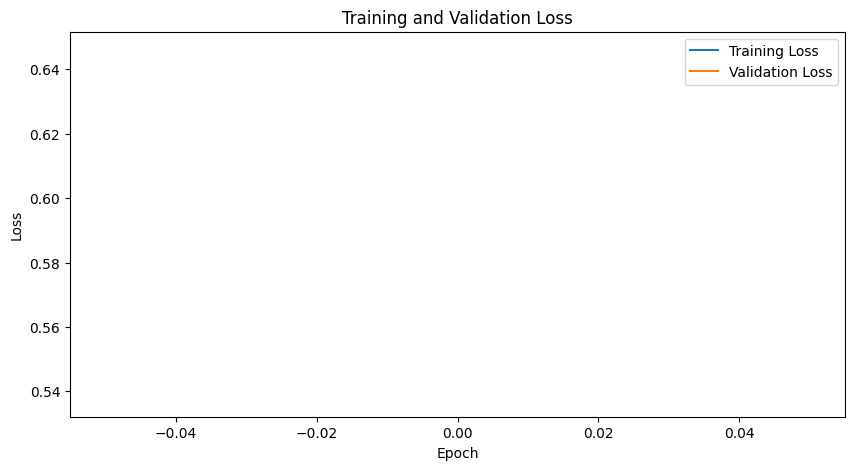

RuntimeError: stack expects each tensor to be equal size, but got [375, 500, 3] at entry 0 and [500, 375, 3] at entry 1

In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RCNN(num_classes=4).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses, val_losses = [], []

for epoch in range(1):
    epoch_train_loss = 0.0
    model.train()
    for regions, gt_bbox, gt_class in train_loader:
        regions = regions.to(device)
        gt_bbox = gt_bbox.to(device)
        gt_class = gt_class.to(device)
        
        class_scores, pred_bbox = model(regions)
         
        loss = compute_loss(class_scores, pred_bbox, gt_bbox, gt_class)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_train_loss += loss.item()
    
    # Validation
    epoch_val_loss = 0.0
    model.eval()
    with torch.no_grad():
        for regions, gt_bbox, gt_class in val_loader:  # Define val_loader similarly
            regions = regions.to(device)
            gt_bbox = gt_bbox.to(device)
            gt_class = gt_class.to(device)
            
            class_scores, pred_bbox = model(regions)
            loss = compute_loss(class_scores, pred_bbox, gt_bbox, gt_class)
            epoch_val_loss += loss.item()
    
    # Logging
    train_loss = epoch_train_loss / len(train_loader)
    val_loss = epoch_val_loss / len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")

# Plot losses
plot_losses(train_losses, val_losses)

# Evaluate on test set
mAP, aps, correct, incorrect, missed = evaluate_test_set(model, test_loader, device)

# Visualize specific test images
test_indices = [0, 15, 27, 29, 38, 74, 77, 87, 92, 145]  # Adjust based on your dataset
for idx in test_indices:
    image, regions, cand_bboxes, gt_bboxes, gt_classes = test_dataset[idx]
    img_pil = Image.fromarray(image)
    
    # Get predictions and process
    regions = regions.to(device)
    class_logits, pred_bboxes = model(regions.unsqueeze(0))
    # ... (process similar to evaluate_test_set)
    
    # Visualize
    detections = {'correct': correct, 'incorrect': incorrect}
    visualized_img = visualize_detections(img_pil, detections, gt_bboxes, gt_classes, LABELS_TO_NAMES)
    visualized_img.show()

In [ ]:
def calculate_class_stats(correct, incorrect, missed):
    stats = {}
    
    # Process correct detections (true positives)
    for det in correct:
        cls = det["class"]
        if cls not in stats:
            stats[cls] = {"tp": 0, "fp": 0, "fn": 0}
        stats[cls]["tp"] += 1
    
    # Process incorrect detections (false positives)
    for det in incorrect:
        cls = det["class"]
        if cls not in stats:
            stats[cls] = {"tp": 0, "fp": 0, "fn": 0}
        stats[cls]["fp"] += 1
    
    # Process missed detections (false negatives)
    for gt in missed:
        cls = gt["class"]
        if cls not in stats:
            stats[cls] = {"tp": 0, "fp": 0, "fn": 0}
        stats[cls]["fn"] += 1
    
    # Calculate metrics
    for cls in stats:
        tp = stats[cls]["tp"]
        fp = stats[cls]["fp"]
        fn = stats[cls]["fn"]
        
        stats[cls]["precision"] = tp / (tp + fp) if (tp + fp) > 0 else 0
        stats[cls]["recall"] = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    return stats

class_stats = calculate_class_stats(correct, incorrect, missed)
for cls, metrics in class_stats.items():
    print(f"Class {LABELS_TO_NAMES[cls]}:")
    print(f"  Precision: {metrics['precision']:.2f}")
    print(f"  Recall: {metrics['recall']:.2f}")

In [ ]:
def plot_confusion_matrix(true_labels, pred_labels, classes):
    cm = confusion_matrix(true_labels, pred_labels)
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)

    # Show all ticks and label them with the respective list entries
    ax.set(xticks=np.arange(len(classes)),
           yticks=np.arange(len(classes)),
           xticklabels=classes, yticklabels=classes,
           xlabel='Predicted', ylabel='True',
           title='Confusion Matrix')

    # Rotate the tick labels and set alignment
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")

    # Loop over data dimensions and create text annotations.
    fmt = 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

    fig.tight_layout()
    plt.show()

In [ ]:
def calculate_average_iou(pred_boxes, gt_boxes):
    ious = []
    for p_box, gt_box in zip(pred_boxes, gt_boxes):
        ious.append(iou(p_box, gt_box))
    return np.mean(ious)

# Use in your evaluation loop:
# correct_pred_boxes = [det['rectangle'] for det in correct]
# correct_gt_boxes = [gt['rectangle'] for gt in matched_gts]  # Need to track these during evaluation
# mean_iou = calculate_average_iou(correct_pred_boxes, correct_gt_boxes)
# print(f"Mean IoU for correct detections: {mean_iou:.3f}")

In [ ]:
# Final outputs
print("\\n=== Final Results ===")
print(f"Overall mAP: {mAP:.4f}")

print("\\nClass-wise Performance:")
for cls in sorted(LABELS_TO_NAMES.keys()):
    if cls == 0: continue  # Skip 'nothing' class
    name = LABELS_TO_NAMES[cls]
    stats = class_stats.get(cls, {'precision':0, 'recall':0})
    print(f"{name}:")
    print(f"  Precision: {stats['precision']*100:.1f}%")
    print(f"  Recall: {stats['recall']*100:.1f}%")